In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [3]:
import zipfile
import os

zip_path = "archive (3).zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [4]:
import os

print(os.listdir(extract_path))

['creditcard.csv']


In [5]:
file_path = extract_path + "/creditcard.csv"

df = pd.read_csv(file_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print(df.shape)

print(df['Class'].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


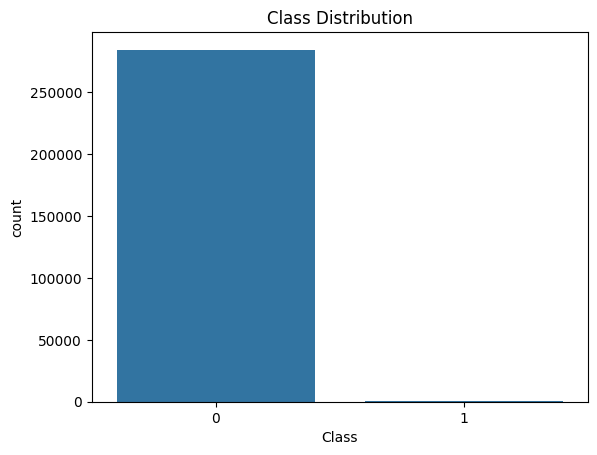

In [7]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

In [8]:
X = df.drop('Class', axis=1)

y = df['Class']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print(X_train.isnull().sum().sum())
print(np.isinf(X_train).sum().sum())

0
0


In [12]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [13]:
print(X_train.shape)
print(y_train.shape)

(227845, 30)
(227845,)


In [14]:
print('Class' in X.columns)

False


In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [17]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56859     5]
 [   18    80]]


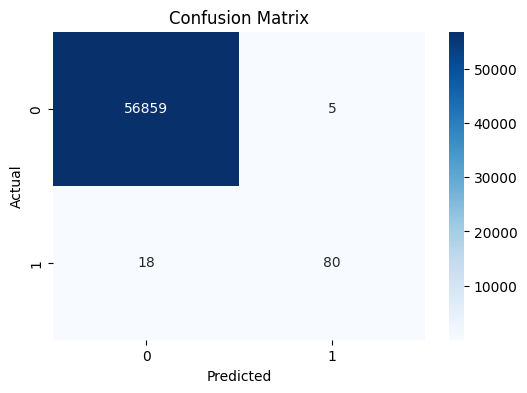

In [19]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [20]:
TN, FP, FN, TP = cm.ravel()

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

TP = 80
TN = 56859
FP = 5
FN = 18


In [21]:
accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9995962220427653
Precision: 0.9411764705882353
Recall   : 0.8163265306122449
F1 Score : 0.8743169398907104


In [22]:
dummy_pred = np.zeros(len(y_test))

In [23]:
print(
    accuracy_score(
        y_test,
        dummy_pred
    )
)

0.9982795547909132


In [24]:
recall_score(
    y_test,
    dummy_pred
)

0.0

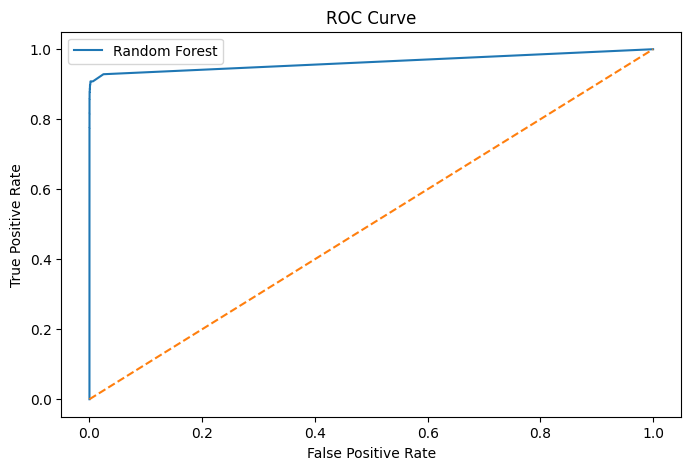

In [25]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [26]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("AUC =", auc)

AUC = 0.9630272515590367


In [27]:
y_test_cap = np.array(y_test)

data = pd.DataFrame({
    'actual': y_test_cap,
    'prob': y_prob
})

data = data.sort_values(
    by='prob',
    ascending=False
)

cum_fraud = np.cumsum(
    data['actual']
)

total_fraud = sum(
    data['actual']
)

cap_y = cum_fraud / total_fraud

cap_x = np.arange(
    1,
    len(data)+1
)/len(data)

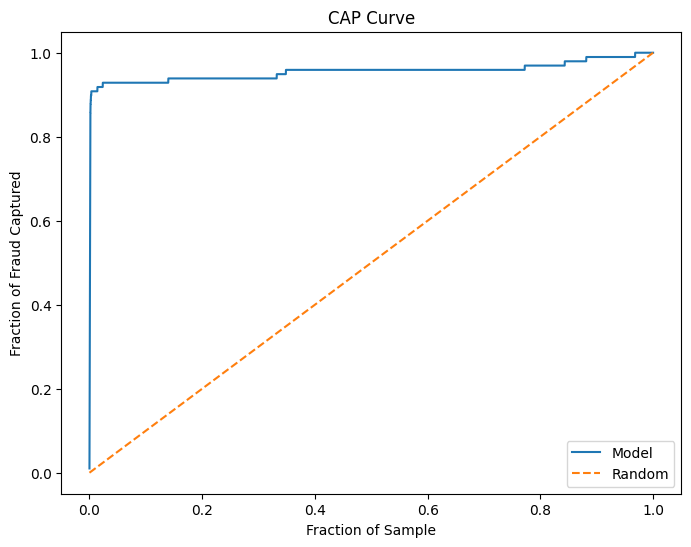

In [28]:
plt.figure(figsize=(8,6))

plt.plot(
    cap_x,
    cap_y,
    label='Model'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    label='Random'
)

plt.xlabel(
    "Fraction of Sample"
)

plt.ylabel(
    "Fraction of Fraud Captured"
)

plt.title(
    "CAP Curve"
)

plt.legend()

plt.show()